In [ ]:
import math

def approximate_exponential(x, sig_digits):
    # Calculate stopping criterion epsilon_s
    es = 0.5 * (10**(2 - sig_digits))
    
    term = 1
    current_approx = term
    ea = x
    n = 1
    
    print(f"Iteration | Approximation | Approx. Error (%)")
    print("-" * 45)
    
    while ea > es:
        prev_approx = current_approx
        term = (term * x) / n  # Calculate next term efficiently
        current_approx += term
        
        # Calculate approximate relative error (Page 5)
        ea = abs((current_approx - prev_approx) / current_approx) * 100
        
        print(f"{n:9d} | {current_approx:13.6f} | {ea:15.6f}%")
        n += 1
        
    return current_approx

# Test for e^0.5 to 3 significant digits
result = approximate_exponential(0.5, 3)
print(f"\nFinal Result: {result}")
print(f"True Value:  {math.exp(0.5)}")


Iteration | Approximation | Approx. Error (%)
---------------------------------------------
        1 |      1.500000 |       33.333333%
        2 |      1.625000 |        7.692308%
        3 |      1.645833 |        1.265823%
        4 |      1.648438 |        0.157978%
        5 |      1.648698 |        0.015795%

Final Result: 1.6486979166666667
True Value:  1.6487212707001282


$f(x)=\sin{x}; X=\frac{\pi}{4}$ 
Find the total error if we 

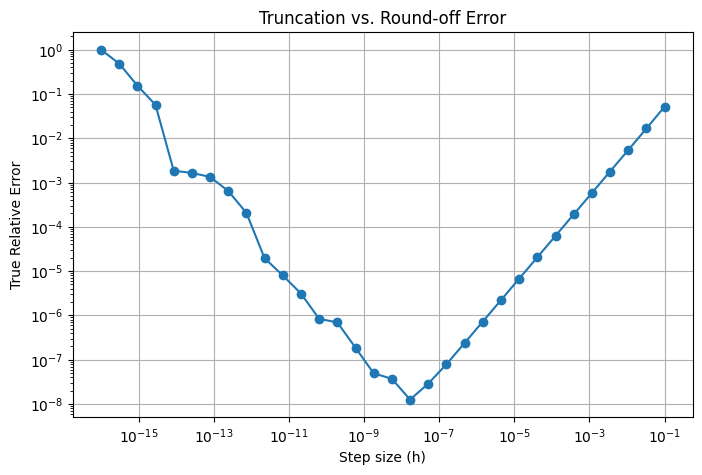

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def study_error_tradeoff():
    x = np.pi / 4
    true_val = np.cos(x) # Derivative of sin(x)
    
    h_values = np.logspace(-1, -16, 32)
    errors = []

    for h in h_values:
        approx = (np.sin(x + h) - np.sin(x)) / h
        # True relative error (Page 4)
        et = abs((true_val - approx) / true_val)
        errors.append(et)

    plt.figure(figsize=(8, 5))
    plt.loglog(h_values, errors, '-o')
    plt.xlabel('Step size (h)')
    plt.ylabel('True Relative Error')
    plt.title('Truncation vs. Round-off Error')
    plt.grid(True)
    plt.show()

study_error_tradeoff()


In [81]:
import scipy as sp
def cos_taylor(x, n):
    term = 1
    for i in range(2, n, 2):
        term += (-1)**(i/2) * term * x**2 / (i*(i-1))
    return term




sp.optimize.bisect(cos_taylor, 1, 2, 10)









np.allclose(np.cos(1), cos_taylor(1, 126), rtol=1e-1, atol=1e-4)
fsolve(cos_taylor(2, 10), -1)

NameError: name 'fsolve' is not defined

In [66]:
?np.allclose

Signature:       np.allclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
Call signature:  np.allclose(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function allclose at 0x000001C0C18EA0C0>
File:            d:\softwares\python\lib\site-packages\numpy\_core\numeric.py
Docstring:      
Returns True if two arrays are element-wise equal within a tolerance.

The tolerance values are positive, typically very small numbers.  The
relative difference (`rtol` * abs(`b`)) and the absolute difference
`atol` are added together to compare against the absolute difference
between `a` and `b`.

.. warning:: The default `atol` is not appropriate for comparing numbers
             with magnitudes much smaller than one (see Notes).

NaNs are treated as equal if they are in the same place and if
``equal_nan=True``.  Infs are treated as equal if they are in the same
place and of the same sign in both arrays.

Parameters
----------
a, b : array_like
    Input arrays to compar

In [50]:
np.cos(1.414213562371514)

np.float64(0.1559436947669362)

In [ ]:
def taylor_cos(x, n_terms):
    approx = 0
    for i in range(n_terms):
        # Taylor series for cos(x) is sum of (-1)^n * x^(2n) / (2n)!
        term = ((-1)**i * x**(2*i)) / math.factorial(2*i)
        approx += term
    return approx

x_val = np.pi / 3
true_val = math.cos(x_val)

for n in [1, 2, 3, 4]: # Corresponds to different truncation points
    approx = taylor_cos(x_val, n)
    error = abs(true_val - approx)
    print(f"Terms: {n} | Approx: {approx:.8f} | Absolute Error: {error:.8e}")


# Numerical Methods Study Guide: Error Analysis & Nonlinear Equations

## Chapter 1: Error Analysis (C01)

### 1. Key Concepts
*   **Approximations and Round-Off Errors:** Numerical methods often rely on approximations rather than exact analytical solutions. This introduces round-off errors due to the limitations of computer memory.
*   **Significant Digits:** These are the digits in a number that can be used with confidence. They consist of all the **certain digits plus one estimated digit**.
*   **Scientific Notation:** Used to remove ambiguity regarding significant digits. For example, the number $45,300$ is ambiguous. Written in scientific notation:
    *   $4.53 \times 10^4$ (3 significant figures)
    *   $4.530 \times 10^4$ (4 significant figures)
    *   $4.5300 \times 10^4$ (5 significant figures)
    *   Similarly, zeros used simply to locate the decimal point are not significant (e.g., $0.00001845$, $0.0001845$, and $0.001845$ all have exactly four significant figures).
*   **Computer Representation of Numbers:** Computers store numbers in binary format using a finite number of bits. This limitation leads to precision issues for continuous real numbers (floating-point numbers).
*   **Subtractive Cancellation:** A critical source of error that occurs when subtracting two nearly equal floating-point numbers. It leads to a massive loss of significant digits.

### 2. Relevant Python Modules and Methods
*   **Built-in `float` and `round()`**: Used to handle standard decimal numbers and round them to a specific number of decimal places.
*   **The `decimal` module (`Decimal`)**: Provides support for fast, correctly rounded decimal floating-point arithmetic, which is crucial for mitigating round-off errors.

#### Python Examples: Error Analysis

**Example 1: Demonstrating Subtractive Cancellation and `round()`**
```python
# Subtractive cancellation occurs when subtracting nearly equal numbers
a = 1.000000000000001
b = 1.000000000000000
result_float = a - b

print(f"Expected: 0.000000000000001")
print(f"Actual float result: {result_float}")

# Using round() to manage displayed significant digits
val = 0.0018456
rounded_val = round(val, 5)
print(f"Original: {val}, Rounded to 5 decimal places: {rounded_val}")

**Example 2: Fixing Precision Issues with `decimal.Decimal`**
python
from decimal import Decimal, getcontext

# Set precision for decimal context
getcontext().prec = 20

# Using Decimal to avoid subtractive cancellation artifacts
a_dec = Decimal('1.000000000000001')
b_dec = Decimal('1.000000000000000')

result_decimal = a_dec - b_dec
print(f"Decimal result: {result_decimal}") # Retains exact intended precision

---

## Chapter 2: Nonlinear Equations (C02)

### 1. Key Concepts
Finding the roots of nonlinear equations $f(x) = 0$ is a fundamental problem in numerical methods. 

*   **The Bisection Method:** 
*   *Theory:* Based on the Intermediate Value Theorem. If a function $f(x)$ is continuous on an interval $[a, b]$ and the signs of $f(a)$ and $f(b)$ are opposite (i.e., $f(a) \cdot f(b) < 0$), then the equation has at least one real root in that interval.
*   *Approach:* The interval is halved iteratively. The sub-interval containing the sign change is retained. It is highly reliable (always converges if initial bounds are correct) but slow.
*   **The Newton-Raphson Method:**
*   *Theory:* An open iterative method that requires a single initial guess $x_0$. It uses the derivative of the function to find the tangent line, extending it to the x-axis to find the next, better approximation $x_{i+1}$.
*   *Approach:* Very fast convergence, but requires the explicit analytical derivative $f'(x)$ and can diverge if the initial guess is poor or if $f'(x)$ approaches zero.
*   **The Secant Method:**
*   *Theory:* A derivative-free alternative to Newton-Raphson. It approximates the derivative using two previous points instead of evaluating the explicit analytical derivative.
*   *Approach:* Requires two initial guesses ($x_{i-1}$ and $x_i$). It is slightly slower than Newton's method but faster than Bisection, and highly useful when the analytical derivative is hard to compute.

### 2. Relevant Python Modules and Methods
*   **Built-in `abs()`**: Crucial for evaluating stopping criteria (e.g., checking if the error $|x_{new} - x_{old}|$ is below a tolerance).
*   **Loops (`while` / `for`)**: Essential for executing the iterative steps of these root-finding algorithms.
*   **The `math` module**: Used for defining the non-linear mathematical functions to be solved.

#### Python Examples: Nonlinear Equations

**Example 1: The Bisection Method**
python
import math

# Define the nonlinear function
def f(x):
return x**2 - 4  # Root is at x = 2 and x = -2

# Bisection Algorithm
def bisection(func, a, b, tol=1e-5):
if func(a) * func(b) >= 0:
return "Bisection method fails: f(a) and f(b) must have opposite signs."

c = a
while abs(b - a) >= tol:
c = (a + b) / 2
if func(c) == 0.0:
break  # Exact root found
if func(c) * func(a) < 0:
b = c  # Root is in left half
else:
a = c  # Root is in right half

return c

root = bisection(f, 0, 5)
print(f"Bisection Root: {root}")

**Example 2: Newton-Raphson and Secant Methods**
python
# Newton-Raphson Method
def newton_raphson(func, deriv_func, x0, tol=1e-5, max_iter=100):
x_i = x0
for _ in range(max_iter):
f_val = func(x_i)
f_deriv_val = deriv_func(x_i)

if f_deriv_val == 0:
return "Derivative is zero, method fails."

x_next = x_i - (f_val / f_deriv_val)

if abs(x_next - x_i) < tol:
return x_next
x_i = x_next
return x_i

# Secant Method
def secant_method(func, x0, x1, tol=1e-5, max_iter=100):
for _ in range(max_iter):
f_x0 = func(x0)
f_x1 = func(x1)

if f_x1 - f_x0 == 0:
return "Division by zero."

x_next = x1 - f_x1 * ((x1 - x0) / (f_x1 - f_x0))

if abs(x_next - x1) < tol:
return x_next

x0, x1 = x1, x_next
return x1

# Setup functions
def f(x): return x**3 - x - 2
def df(x): return 3*x**2 - 1

print(f"Newton-Raphson Root: {newton_raphson(f, df, 1.5)}")
print(f"Secant Method Root: {secant_method(f, 1.0, 2.0)}")


I have provided the information in a copyable format as requested. If you need me to retrieve the exact mathematical formulas for the algorithms or dig deeper into specific stopping criteria from the PDFs, please let me know and I can retrieve further details in a follow-up!